In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import gdown
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import defaultdict
import pickle

DATASET DOWNLOAD

In [2]:
def download_buddha_dataset():
    """Download Buddha dataset from Google Drive"""
    print("\n Downloading Buddha dataset...")

    # Create directories
    os.makedirs('/content/buddha_images', exist_ok=True)
    os.makedirs('/content/outputs/matches', exist_ok=True)
    os.makedirs('/content/outputs/point_clouds', exist_ok=True)

    # Download from Google Drive
    url = "https://drive.google.com/drive/folders/1PFrGwrTAVvezGXptI4Jgm3MiMIshoa_b"
    try:
        gdown.download_folder(url=url, output='/content/buddha_images', quiet=False)
        print(" Dataset downloaded successfully!")
    except:
        print(f"  Download Failed from URL : {url}")

    return '/content/buddha_images'

# Download Dataset
buddha_path = download_buddha_dataset()

Retrieving folder contents


Processing file 1LwPJFqsXjWDZaPMRhp4GfET_eYTr71Nj buddha_001.png
Processing file 1G-lTVbzrX98H7HvZy9L4JcvVcMdD6zYn buddha_002.png
Processing file 1ZZLTnAkvqvs2uAZgzFyIyNd-sGPyp5Am buddha_003.png
Processing file 1Iujiz7dxPD94i4rjson13az4cNpeEj9h buddha_004.png
Processing file 1UVs_3jFojlDfeIGJdroYH7BAgHqDW93S buddha_005.png
Processing file 1ZNO_PsxvZI0vfpjfn78Ar1Fq2-Nw5AdA buddha_006.png
Processing file 1SN8zc2BHYWRz-BlDzVWIzVQkUU3dpqXq buddha_007.png
Processing file 1mFECXK9qekPMlbDCmzdJL_H1aE4Xl808 buddha_008.png
Processing file 1syfgh63L3ThQgnPnp3rjTPabiVazG7kN buddha_009.png
Processing file 1qiUBRSwzW5Fz-55StiVQ_vNe2Y7FeFJc buddha_010.png
Processing file 1L3A9omQyJ5Ulhfim8fFy8lvmf-AIHv6w buddha_011.png
Processing file 1OXZSeZWrXn6J1cEtG1K3JPT35PHSUp2d buddha_012.png
Processing file 18QWz6a9l-2eo1gCigVSW3gRfkxRLV6bN buddha_013.png
Processing file 1I7jvEW2znnlUIHQ5v_uGM80sxhxa9g2c buddha_014.png
Processing file 1seHLtalCZV50ZLsa2m4JReczp50iyc3B buddha_015.png
Processing file 1ej7TRlb3

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1LwPJFqsXjWDZaPMRhp4GfET_eYTr71Nj
To: /content/buddha_images/buddha_001.png
100%|██████████| 2.52M/2.52M [00:00<00:00, 276MB/s]
Downloading...
From: https://drive.google.com/uc?id=1G-lTVbzrX98H7HvZy9L4JcvVcMdD6zYn
To: /content/buddha_images/buddha_002.png
100%|██████████| 2.01M/2.01M [00:00<00:00, 256MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ZZLTnAkvqvs2uAZgzFyIyNd-sGPyp5Am
To: /content/buddha_images/buddha_003.png
100%|██████████| 2.32M/2.32M [00:00<00:00, 274MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Iujiz7dxPD94i4rjson13az4cNpeEj9h
To: /content/buddha_images/buddha_004.png
100%|██████████| 2.21M/2.21M [00:00<00:00, 261MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UVs_3jFojlDfeIGJdroYH7BAgHqDW93S
To: /content/buddha_images/buddha_005.png
100%|██████████| 2.19M/2.19M [00:00<00:00, 245M

  Download Failed from URL : https://drive.google.com/drive/folders/1PFrGwrTAVvezGXptI4Jgm3MiMIshoa_b


In [3]:
def load_images(folder_path):
    """Load all images from folder"""
    print(f"\n Loading images from {folder_path}...")

    image_paths = sorted([p for p in Path(folder_path).glob("*")
                         if p.suffix.lower() in ['.jpg', '.png', '.jpeg']])

    images = {}
    for path in image_paths:
        img = cv2.imread(str(path))
        if img is not None:
            images[str(path)] = img
            print(f"    Loaded: {path.name} - Shape: {img.shape}")

    print(f"\n Total images loaded: {len(images)}")
    return images

# Load images
images = load_images(buddha_path)


 Loading images from /content/buddha_images...
    Loaded: buddha_001.png - Shape: (1920, 1080, 3)
    Loaded: buddha_002.png - Shape: (1920, 1080, 3)
    Loaded: buddha_003.png - Shape: (1920, 1080, 3)
    Loaded: buddha_004.png - Shape: (1920, 1080, 3)
    Loaded: buddha_005.png - Shape: (1920, 1080, 3)
    Loaded: buddha_006.png - Shape: (1920, 1080, 3)
    Loaded: buddha_007.png - Shape: (1920, 1080, 3)
    Loaded: buddha_008.png - Shape: (1920, 1080, 3)
    Loaded: buddha_009.png - Shape: (1920, 1080, 3)
    Loaded: buddha_010.png - Shape: (1920, 1080, 3)
    Loaded: buddha_011.png - Shape: (1920, 1080, 3)
    Loaded: buddha_012.png - Shape: (1920, 1080, 3)
    Loaded: buddha_013.png - Shape: (1920, 1080, 3)
    Loaded: buddha_014.png - Shape: (1920, 1080, 3)
    Loaded: buddha_015.png - Shape: (1920, 1080, 3)
    Loaded: buddha_016.png - Shape: (1920, 1080, 3)
    Loaded: buddha_017.png - Shape: (1920, 1080, 3)
    Loaded: buddha_018.png - Shape: (1920, 1080, 3)
    Loaded: budd

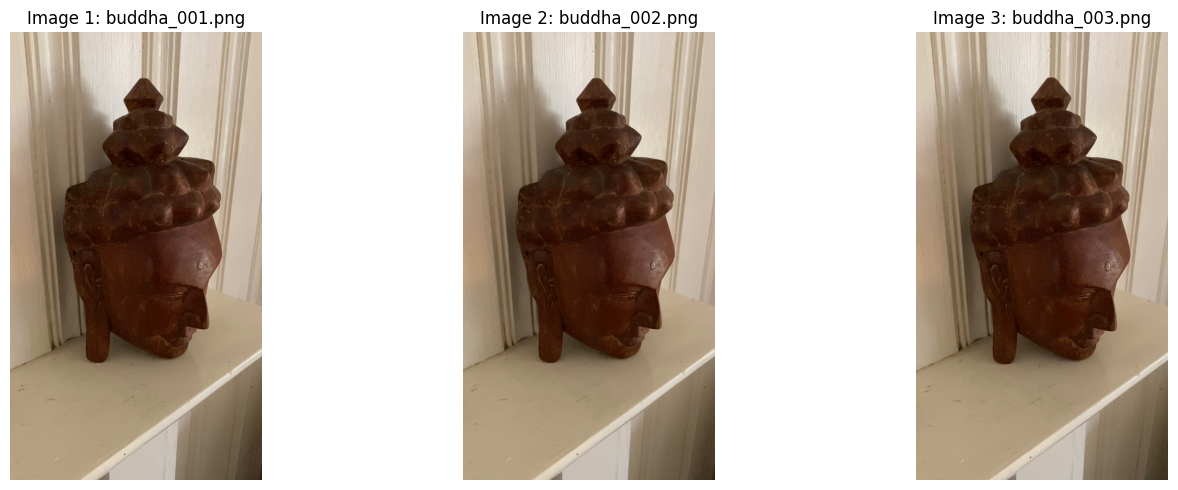

In [4]:
# Display first 3 images as sample
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (path, img) in enumerate(list(images.items())[:3]):
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Image {i+1}: {Path(path).name}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

FEATURE MATCHING

In [5]:
def extract_sift_features(images):
    """Extract SIFT features from all images"""
    print("\n Extracting SIFT features...")

    sift = cv2.SIFT_create(nfeatures=5000, contrastThreshold=0.04, edgeThreshold=10)
    features = {}

    for img_path, img in images.items():
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, desc = sift.detectAndCompute(gray, None)

        if desc is not None:
            features[img_path] = {
                'keypoints': kp,
                'descriptors': desc,
                'image_size': img.shape[:2],
                'image': img
            }
            print(f"    {Path(img_path).name}: {len(kp)} features")

    return features

# Extract features
features = extract_sift_features(images)


 Extracting SIFT features...
    buddha_001.png: 1145 features
    buddha_002.png: 629 features
    buddha_003.png: 871 features
    buddha_004.png: 821 features
    buddha_005.png: 527 features
    buddha_006.png: 651 features
    buddha_007.png: 719 features
    buddha_008.png: 780 features
    buddha_009.png: 606 features
    buddha_010.png: 468 features
    buddha_011.png: 487 features
    buddha_012.png: 754 features
    buddha_013.png: 548 features
    buddha_014.png: 443 features
    buddha_015.png: 895 features
    buddha_016.png: 764 features
    buddha_017.png: 714 features
    buddha_018.png: 631 features
    buddha_019.png: 700 features
    buddha_020.png: 909 features
    buddha_021.png: 831 features
    buddha_022.png: 822 features
    buddha_023.png: 364 features
    buddha_024.png: 609 features


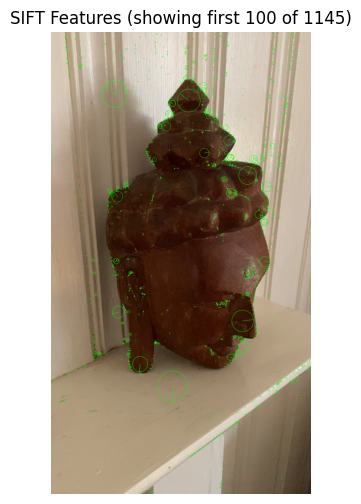

In [6]:
# Visualize features on first image
first_path = list(images.keys())[0]
img_with_kp = cv2.drawKeypoints(images[first_path], features[first_path]['keypoints'][:],
                                None, color=(0,255,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT Features (showing first 100 of {len(features[first_path]["keypoints"])})')
plt.axis('off')
plt.show()

In [7]:
def match_features_pair(feat1, feat2, ratio_threshold=0.75):
    """Match features between two images using FLANN matcher"""

    if feat1['descriptors'] is None or feat2['descriptors'] is None:
        return np.array([]), np.array([]), []

    # FLANN matcher for SIFT
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)

    flann = cv2.FlannBasedMatcher(index_params, search_params)

    try:
        matches = flann.knnMatch(feat1['descriptors'], feat2['descriptors'], k=2)
    except:
        return np.array([]), np.array([]), []

    # Lowe's ratio test
    good_matches = []
    pts1 = []
    pts2 = []

    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < ratio_threshold * n.distance:
                good_matches.append(m)
                pts1.append(feat1['keypoints'][m.queryIdx].pt)
                pts2.append(feat2['keypoints'][m.trainIdx].pt)

    return np.array(pts1, dtype=np.float32), np.array(pts2, dtype=np.float32), good_matches

In [8]:
# Match features between first two images
img_paths = list(features.keys())
feat1 = features[img_paths[0]]
feat2 = features[img_paths[1]]
pts1, pts2, good_matches = match_features_pair(feat1, feat2)

print(f"\n Matching Results (Image 0-1):")
print(f"   Total matches found: {len(good_matches)}")
print(f"   After ratio test: {len(pts1)} good matches")


 Matching Results (Image 0-1):
   Total matches found: 345
   After ratio test: 345 good matches


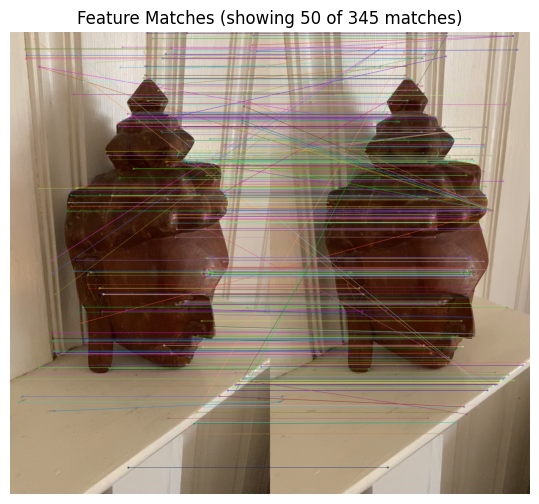

In [9]:
# Visualize matches
img1 = images[img_paths[0]]
img2 = images[img_paths[1]]
match_img = cv2.drawMatches(img1, feat1['keypoints'], img2, feat2['keypoints'],
                            good_matches[:], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15, 6))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title(f'Feature Matches (showing 50 of {len(good_matches)} matches)')
plt.axis('off')
plt.show()

In [10]:
!pip install kornia==0.7.0 torch torchvision

In [11]:
import torch
from kornia.feature import LoFTR

/usr/local/lib/python3.12/dist-packages/kornia/feature/lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
loftr = LoFTR(pretrained='outdoor').to(device).eval()

loftr_features_all = {}


Using device: cuda


In [13]:
def match_features_pair(feat1, feat2):
    """
    Match features between two images using LoFTR (ML-based matcher).
    Returns matched points and confidence.
    """
    # Retrieve raw images
    img1 = feat1.get('image')
    img2 = feat2.get('image')

    if img1 is None or img2 is None:
        print("Error: Image data not found in feature dictionaries.")
        return np.array([]), np.array([]), np.array([])

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Resize for LoFTR (optional but recommended)
    target_size = (640, 480)
    gray1_resized = cv2.resize(gray1, target_size)
    gray2_resized = cv2.resize(gray2, target_size)

    # Scale factors for converting back to original coordinates
    scale1 = (img1.shape[1] / target_size[0], img1.shape[0] / target_size[1])
    scale2 = (img2.shape[1] / target_size[0], img2.shape[0] / target_size[1])

    # Convert to torch tensors
    t1 = torch.from_numpy(gray1_resized)[None, None].float().to(device) / 255.
    t2 = torch.from_numpy(gray2_resized)[None, None].float().to(device) / 255.

    # Run LoFTR
    print(f"  Running LoFTR matching...")
    with torch.no_grad():
        output = loftr({'image0': t1, 'image1': t2})

    # Extract matches
    pts1 = output['keypoints0'].cpu().numpy()
    pts2 = output['keypoints1'].cpu().numpy()
    confidence = output['confidence'].cpu().numpy()

    # Scale back to original coordinates
    pts1[:, 0] *= scale1[0]
    pts1[:, 1] *= scale1[1]
    pts2[:, 0] *= scale2[0]
    pts2[:, 1] *= scale2[1]

    print(f"  Found {len(pts1)} matches")
    print(f"  Confidence: mean={confidence.mean():.3f}, min={confidence.min():.3f}, max={confidence.max():.3f}")

    return np.array(pts1, dtype=np.float32), np.array(pts2, dtype=np.float32), np.array(confidence, dtype=np.float32)


In [14]:
image_list = list(images.keys()) # Use all images
loftr_features_all = {} # Re-initialize for this run

print("\nPerforming LoFTR feature matching for all image pairs...")

for i in range(len(image_list) - 1):
    print(f"Processing pair: {Path(image_list[i]).name} - {Path(image_list[i+1]).name}")
    feat1_data = features[image_list[i]]
    feat2_data = features[image_list[i+1]]

    pts1_loftr, pts2_loftr, confidence_loftr = match_features_pair(feat1_data, feat2_data)

    if len(pts1_loftr) > 0:
        # Store for saving to file
        loftr_features_all[f'pair_{i}_{i+1}'] = {
            'pts1': pts1_loftr,
            'pts2': pts2_loftr,
            'confidence': confidence_loftr,
            'img1_path': image_list[i],
            'img2_path': image_list[i+1],
            'img1_shape': feat1_data['image_size'],
            'img2_shape': feat2_data['image_size']
        }

        # Also store in the main 'features' dictionary for potential downstream use
        if 'loftr_matches' not in features[image_list[i]]:
            features[image_list[i]]['loftr_matches'] = {}
        features[image_list[i]]['loftr_matches']['to_next'] = {
            'pts1': pts1_loftr,
            'pts2': pts2_loftr,
            'confidence': confidence_loftr
        }
        print(f"  Stored {len(pts1_loftr)} LoFTR matches for pair {i}-{i+1}")
    else:
        print(f"  No LoFTR matches found for pair {i}-{i+1}")

print("\nLoFTR feature matching for all pairs complete.")



Performing LoFTR feature matching for all image pairs...
Processing pair: buddha_001.png - buddha_002.png
  Running LoFTR matching...
  Found 4236 matches
  Confidence: mean=0.945, min=0.205, max=1.000
  Stored 4236 LoFTR matches for pair 0-1
Processing pair: buddha_002.png - buddha_003.png
  Running LoFTR matching...
  Found 3843 matches
  Confidence: mean=0.713, min=0.200, max=1.000
  Stored 3843 LoFTR matches for pair 1-2
Processing pair: buddha_003.png - buddha_004.png
  Running LoFTR matching...
  Found 3626 matches
  Confidence: mean=0.697, min=0.200, max=0.999
  Stored 3626 LoFTR matches for pair 2-3
Processing pair: buddha_004.png - buddha_005.png
  Running LoFTR matching...
  Found 3053 matches
  Confidence: mean=0.633, min=0.200, max=0.999
  Stored 3053 LoFTR matches for pair 3-4
Processing pair: buddha_005.png - buddha_006.png
  Running LoFTR matching...
  Found 3047 matches
  Confidence: mean=0.642, min=0.200, max=0.999
  Stored 3047 LoFTR matches for pair 4-5
Processing p

In [15]:
# Save as pickle
save_path = '/content/outputs/loftr_features.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(loftr_features_all, f)
print(f"  Saved to: {save_path}")

# Also save as numpy arrays for easier inspection
np_save_path = '/content/outputs/loftr_features.npz'
np_data = {}
for key, data in loftr_features_all.items():
    np_data[f'{key}_pts1'] = data['pts1']
    np_data[f'{key}_pts2'] = data['pts2']
    np_data[f'{key}_conf'] = data['confidence']
np.savez_compressed(np_save_path, **np_data)
print(f"  Saved numpy arrays to: {np_save_path}")

  Saved to: /content/outputs/loftr_features.pkl
  Saved numpy arrays to: /content/outputs/loftr_features.npz


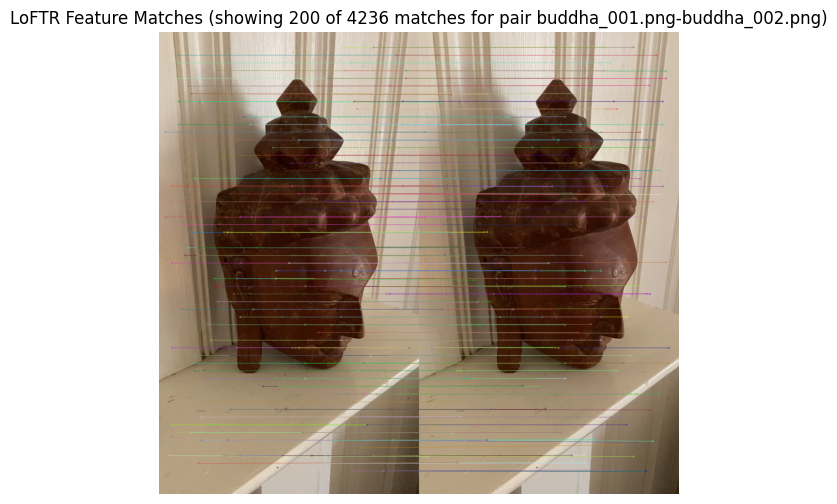

In [16]:
if loftr_features_all:
    # Select the first pair for visualization
    first_pair_key = list(loftr_features_all.keys())[0]
    first_pair_data = loftr_features_all[first_pair_key]

    img1_path = first_pair_data['img1_path']
    img2_path = first_pair_data['img2_path']
    pts1 = first_pair_data['pts1']
    pts2 = first_pair_data['pts2']

    img1 = images[img1_path]
    img2 = images[img2_path]

    # Only draw a subset of matches if there are too many for better visibility
    num_matches_to_draw = min(200, len(pts1)) # Limit to 200 matches for drawing
    draw_indices = np.random.choice(len(pts1), num_matches_to_draw, replace=False)

    match_img = cv2.drawMatches(
        img1,
        [cv2.KeyPoint(x=p[0], y=p[1], size=1) for p in pts1[draw_indices]],
        img2,
        [cv2.KeyPoint(x=p[0], y=p[1], size=1) for p in pts2[draw_indices]],
        [cv2.DMatch(i, i, 0) for i in range(num_matches_to_draw)], # Dummy DMatch objects
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(15, 6))
    plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    plt.title(f'LoFTR Feature Matches (showing {num_matches_to_draw} of {len(pts1)} matches for pair {Path(img1_path).name}-{Path(img2_path).name})')
    plt.axis('off')
    plt.show()
else:
    print("No LoFTR matches available for visualization.")


In [17]:
# Camera intrinsics
K = np.array([
    [1500, 0, 960],
    [0, 1500, 540],
    [0, 0, 1]
], dtype=np.float32)

print(" Camera Intrinsics Matrix K:")
print(K)

 Camera Intrinsics Matrix K:
[[1.5e+03 0.0e+00 9.6e+02]
 [0.0e+00 1.5e+03 5.4e+02]
 [0.0e+00 0.0e+00 1.0e+00]]


OPENCV IMPLENMENTATION

In [18]:
# Compute Fundamental Matrix
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, 1.0, 0.99)

if F is not None:
    pts1_inliers = pts1[mask.ravel() == 1]
    pts2_inliers = pts2[mask.ravel() == 1]

    print(f"\n Fundamental Matrix Results:")
    print(f"   Inliers: {len(pts1_inliers)}/{len(pts1)} ({100*len(pts1_inliers)/len(pts1):.1f}%)")

    # Compute Essential Matrix
    E = K.T @ F @ K

    # Validate matrices
    print("\n Matrix Validation:")

    # Check F rank
    rank_F = np.linalg.matrix_rank(F)
    U_f, S_f, Vt_f = np.linalg.svd(F)
    print(f"\nFundamental Matrix F:")
    print(f"   Rank: {rank_F} {'' if rank_F == 2 else ''} (should be 2)")
    print(f"   Singular values: [{S_f[0]:.4f}, {S_f[1]:.4f}, {S_f[2]:.6f}]")

    # Check E properties
    U_e, S_e, Vt_e = np.linalg.svd(E)
    print(f"\nEssential Matrix E:")
    print(f"   Singular values: [{S_e[0]:.4f}, {S_e[1]:.4f}, {S_e[2]:.6f}]")
    print(f"   Ratio S[0]/S[1]: {S_e[0]/S_e[1]:.4f} {'' if abs(S_e[0]/S_e[1] - 1) < 0.1 else ''}")

    # Recover pose
    _, R, t, pose_mask = cv2.recoverPose(E, pts1_inliers, pts2_inliers, K)
    print(f"\nPose Recovery:")
    print(f"   Rotation det(R): {np.linalg.det(R):.4f}")
    print(f"   Points with positive depth: {np.sum(pose_mask)}/{len(pose_mask)}")


 Fundamental Matrix Results:
   Inliers: 3283/4236 (77.5%)

 Matrix Validation:

Fundamental Matrix F:
   Rank: 2  (should be 2)
   Singular values: [3.2735, 2.2735, 0.000000]

Essential Matrix E:
   Singular values: [4076.7499, 4069.3541, 0.000000]
   Ratio S[0]/S[1]: 1.0018 

Pose Recovery:
   Rotation det(R): 1.0000
   Points with positive depth: 0/3283


In [19]:
class FundamentalMatrixManual:
    """Manual implementation of Fundamental Matrix computation"""

    def __init__(self):
        self.F = None

    def normalize_points(self, points):
        """Hartley normalization for numerical stability"""
        points = np.array(points, dtype=np.float64)

        # Centroid
        centroid = np.mean(points, axis=0)

        # Shift to origin
        shifted = points - centroid

        # Scale
        avg_dist = np.mean(np.sqrt(np.sum(shifted**2, axis=1)))
        scale = np.sqrt(2) / avg_dist if avg_dist > 0 else 1.0

        # Transformation matrix
        T = np.array([
            [scale, 0, -scale * centroid[0]],
            [0, scale, -scale * centroid[1]],
            [0, 0, 1]
        ])

        # Apply transformation
        points_h = np.column_stack([points, np.ones(len(points))])
        points_norm = (T @ points_h.T).T

        return points_norm[:, :2], T

    def compute_fundamental_8point(self, pts1, pts2):
        """8-point algorithm for fundamental matrix"""

        n = len(pts1)
        if n < 8:
            raise ValueError(f"Need at least 8 points, got {n}")

        # Normalize
        pts1_norm, T1 = self.normalize_points(pts1)
        pts2_norm, T2 = self.normalize_points(pts2)

        # Build constraint matrix A
        A = np.zeros((n, 9))
        for i in range(n):
            x1, y1 = pts1_norm[i]
            x2, y2 = pts2_norm[i]
            A[i] = [x2*x1, x2*y1, x2, y2*x1, y2*y1, y2, x1, y1, 1]

        # Solve using SVD
        _, _, Vt = np.linalg.svd(A)
        F = Vt[-1].reshape(3, 3)

        # Enforce rank-2 constraint
        U, S, Vt = np.linalg.svd(F)
        S[2] = 0
        F = U @ np.diag(S) @ Vt

        # Denormalize
        F = T2.T @ F @ T1

        # Normalize F
        if abs(F[2, 2]) > 1e-10:
            F = F / F[2, 2]
        else:
            F = F / np.linalg.norm(F, 'fro')

        self.F = F
        return F

    def compute_fundamental_ransac(self, pts1, pts2, threshold=1.0, max_iters=2000):
        """RANSAC for robust fundamental matrix estimation"""

        n = len(pts1)
        best_F = None
        best_inliers = []
        best_count = 0

        for _ in range(max_iters):
            # Random 8 points
            idx = np.random.choice(n, min(8, n), replace=False)
            sample_pts1 = pts1[idx]
            sample_pts2 = pts2[idx]

            try:
                # Compute F from sample
                F = self.compute_fundamental_8point(sample_pts1, sample_pts2)

                # Count inliers
                errors = self.compute_epipolar_errors(F, pts1, pts2)
                inliers = errors < threshold
                inlier_count = np.sum(inliers)

                if inlier_count > best_count:
                    best_count = inlier_count
                    best_F = F
                    best_inliers = inliers
            except:
                continue

        # Refine with all inliers
        if best_count >= 8:
            inlier_pts1 = pts1[best_inliers]
            inlier_pts2 = pts2[best_inliers]
            best_F = self.compute_fundamental_8point(inlier_pts1, inlier_pts2)

        self.F = best_F
        return best_F, best_inliers

    def compute_epipolar_errors(self, F, pts1, pts2):
        """Compute symmetric epipolar distance"""
        n = len(pts1)
        pts1_h = np.column_stack([pts1, np.ones(n)])
        pts2_h = np.column_stack([pts2, np.ones(n)])

        errors = []
        for i in range(n):
            x1, x2 = pts1_h[i], pts2_h[i]

            # Epipolar lines
            l2 = F @ x1
            l1 = F.T @ x2

            # Sampson distance
            num = abs(x2 @ F @ x1)
            denom = np.sqrt(l1[0]**2 + l1[1]**2 + l2[0]**2 + l2[1]**2)

            if denom > 0:
                errors.append(num / denom)
            else:
                errors.append(np.inf)

        return np.array(errors)

In [20]:
class EssentialMatrixManual:
    """Manual implementation of Essential Matrix computation"""

    def __init__(self, K):
        self.K = K
        self.E = None

    def compute_from_fundamental(self, F):
        """E = K^T F K"""
        E = self.K.T @ F @ self.K

        # Enforce constraints
        U, S, Vt = np.linalg.svd(E)

        # Singular values should be [1, 1, 0]
        S = np.array([1, 1, 0])

        # Ensure proper rotation
        # Determinant of a rotation matrix should be 1. If -1, flip the signs.
        if np.linalg.det(U) < 0:
            U = -U
        if np.linalg.det(Vt) < 0:
            Vt = -Vt

        E = U @ np.diag(S) @ Vt
        self.E = E
        return E

    def decompose(self, E):
        """Decompose E into R and t"""
        U, _, Vt = np.linalg.svd(E)

        # Ensure proper rotation matrix properties
        # Determinant of a rotation matrix should be 1. If -1, flip the signs.
        if np.linalg.det(U) < 0:
            U = -U
        if np.linalg.det(Vt) < 0:
            Vt = -Vt

        # W matrix for decomposition
        W = np.array([[0, -1, 0], [1, 0, 0], [0, 0, 1]])

        # Four possible solutions for R and t
        R1 = U @ W @ Vt
        R2 = U @ W.T @ Vt
        t = U[:, 2] # Translation vector is the third column of U (up to a scale factor)

        solutions = [(R1, t), (R1, -t), (R2, t), (R2, -t)]

        return solutions

    def select_pose(self, solutions, pts1, pts2):
        """Select correct pose using cheirality check (points must be in front of both cameras)"""
        best_solution = None
        max_front = 0

        # Camera 1 is at origin with identity rotation
        P1 = self.K @ np.hstack([np.eye(3), np.zeros((3, 1))])

        for R, t in solutions:
            # Ensure R is a valid rotation matrix (det should be 1)
            if np.linalg.det(R) < 0:
                continue

            P2 = self.K @ np.hstack([R, t.reshape(3, 1)])

            # Sample points for cheirality check (to avoid costly triangulation of all points)
            n_test = min(100, len(pts1)) # Use up to 100 points for robustness
            indices = np.random.choice(len(pts1), n_test, replace=False)

            front_count = 0
            for idx in indices:
                # Triangulate a single point with the current pose hypothesis
                X = Triangulation(self.K).triangulate_point(pts1[idx], pts2[idx], P1, P2, apply_depth_filter=False) # Do not apply depth filter here, as it will be done in filter_points
                if X is not None:
                    # Check depth in both cameras (Z-coordinate in camera frame)
                    if X[2] > 0: # Point is in front of camera 1
                        X_cam2 = R @ X + t
                        if X_cam2[2] > 0: # Point is in front of camera 2
                            front_count += 1

            if front_count > max_front:
                max_front = front_count
                best_solution = (R, t)

        # If no solution found with positive depth points, return None
        if max_front == 0 and len(solutions) > 0: # Ensure at least some points were tested
             print("       Warning: No pose found with points in front of both cameras. Returning first solution if available.")
             return solutions[0] # Fallback to first solution, although it might not be optimal
        return best_solution


TRIANGULATION

In [21]:
class Triangulation:
    """Simple but effective triangulation"""

    def __init__(self, K):
        self.K = K

    def triangulate_points(self, pts1, pts2, R, t):
        """Triangulate points from two views"""
        P1 = self.K @ np.hstack([np.eye(3), np.zeros((3, 1))])
        P2 = self.K @ np.hstack([R, t.reshape(3, 1)])

        pts_3d = []
        for i in range(len(pts1)):
            pt_3d = self.triangulate_point(pts1[i], pts2[i], P1, P2, apply_depth_filter=False)
            if pt_3d is not None:
                pts_3d.append(pt_3d)

        return np.array(pts_3d) if pts_3d else np.array([])

    def triangulate_point(self, pt1, pt2, P1, P2, apply_depth_filter=True):
        """Triangulate single point using DLT"""
        A = np.zeros((4, 4))
        A[0] = pt1[0] * P1[2] - P1[0] # (x1*P1_z - P1_x)
        A[1] = pt1[1] * P1[2] - P1[1] # (y1*P1_z - P1_y)
        A[2] = pt2[0] * P2[2] - P2[0] # (x2*P2_z - P2_x)
        A[3] = pt2[1] * P2[2] - P2[1] # (y2*P2_z - P2_y)

        _, _, Vt = np.linalg.svd(A)
        X = Vt[-1] # The last column of V (or last row of Vt) is the solution

        if abs(X[3]) < 1e-10: # Avoid division by zero, point at infinity
            return None

        pt_3d = X[:3] / X[3] # Normalize to get homogeneous coordinates [X, Y, Z, 1]

        return pt_3d

    def filter_points(self, pts_3d, pts1, pts2, R, t, min_depth=0.1, max_depth=50.0, max_error=5.0):
        """Filter points based on reprojection error and cheirality"""
        if len(pts_3d) == 0:
            return np.array([]), np.array([]), np.array([])

        P1 = self.K @ np.hstack([np.eye(3), np.zeros((3, 1))])
        P2 = self.K @ np.hstack([R, t.reshape(3, 1)])

        valid_mask = np.ones(len(pts_3d), dtype=bool)

        # Check positive depth (cheirality) and reasonable depth range
        depths1 = pts_3d[:, 2]
        pts_cam2 = (R @ pts_3d.T + t.reshape(3, 1)).T
        depths2 = pts_cam2[:, 2]

        valid_mask &= (depths1 > min_depth) & (depths1 < max_depth)
        valid_mask &= (depths2 > min_depth) & (depths2 < max_depth)

        # Check reprojection errors
        for i in range(len(pts_3d)):
            if not valid_mask[i]:
                continue

            # Project to both cameras and check error
            pt_h = np.append(pts_3d[i], 1)

            proj1_h = P1 @ pt_h
            if abs(proj1_h[2]) > 1e-10:
                proj1 = proj1_h[:2] / proj1_h[2]
                error1 = np.linalg.norm(proj1 - pts1[i])
            else:
                error1 = float('inf')

            proj2_h = P2 @ pt_h
            if abs(proj2_h[2]) > 1e-10:
                proj2 = proj2_h[:2] / proj2_h[2]
                error2 = np.linalg.norm(proj2 - pts2[i])
            else:
                error2 = float('inf')

            if error1 > max_error or error2 > max_error:
                valid_mask[i] = False

        return pts_3d[valid_mask], pts1[valid_mask], pts2[valid_mask]


In [22]:
def process_all_sift_pairs(features, images, K, max_images=24, min_depth=0.1, max_depth=50.0, max_reproj_error=5.0):
    """Process all consecutive image pairs using SIFT features and manual F/E matrix."""

    image_list = list(features.keys())[:max_images]
    triangulator = Triangulation(K)
    fundamental_manual = FundamentalMatrixManual()
    essential_manual = EssentialMatrixManual(K)
    all_reconstructions = []

    print(f"\n Processing {len(image_list)-1} consecutive pairs with SIFT features...")

    for i in range(len(image_list) - 1):
        img_path1 = image_list[i]
        img_path2 = image_list[i + 1]

        feat1_data = features[img_path1]
        feat2_data = features[img_path2]

        def _sift_match_features_pair_local(feat1_loc, feat2_loc, ratio_threshold=0.75):
            if feat1_loc['descriptors'] is None or feat2_loc['descriptors'] is None:
                return np.array([]), np.array([]), []

            FLANN_INDEX_KDTREE = 1
            index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
            search_params = dict(checks=50)

            flann = cv2.FlannBasedMatcher(index_params, search_params)

            try:
                matches = flann.knnMatch(feat1_loc['descriptors'], feat2_loc['descriptors'], k=2)
            except:
                return np.array([]), np.array([]), []

            good_matches = []
            pts1 = []
            pts2 = []

            for match_pair in matches:
                if len(match_pair) == 2:
                    m, n = match_pair
                    if m.distance < ratio_threshold * n.distance:
                        good_matches.append(m)
                        pts1.append(feat1_loc['keypoints'][m.queryIdx].pt)
                        pts2.append(feat2_loc['keypoints'][m.trainIdx].pt)

            return np.array(pts1, dtype=np.float32), np.array(pts2, dtype=np.float32), good_matches

        pts1, pts2, good_matches = _sift_match_features_pair_local(feat1_data, feat2_data)

        if len(pts1) < 8: # Need at least 8 points for 8-point algorithm
            print(f"   Pair {i}-{i+1}: Too few SIFT matches ({len(pts1)}) after ratio test.")
            continue

        # Compute F matrix using manual RANSAC
        F, inliers_mask_F = fundamental_manual.compute_fundamental_ransac(pts1, pts2, threshold=1.0)

        if F is None or np.sum(inliers_mask_F) < 8:
            print(f"   Pair {i}-{i+1}: Fundamental matrix estimation failed or too few RANSAC inliers.")
            continue

        pts1_inliers = pts1[inliers_mask_F]
        pts2_inliers = pts2[inliers_mask_F]

        # Compute E matrix and recover pose using manual methods
        E = essential_manual.compute_from_fundamental(F)
        pose_solutions = essential_manual.decompose(E)
        R, t = essential_manual.select_pose(pose_solutions, pts1_inliers, pts2_inliers)

        if R is None or t is None:
            print(f"   Pair {i}-{i+1}: Pose recovery failed.")
            continue

        # Triangulate
        pts_3d = triangulator.triangulate_points(pts1_inliers, pts2_inliers, R, t)

        if len(pts_3d) > 0:
            # Need to pass the original pts1_inliers corresponding to the triangulated points
            # to filter_points for color extraction later.
            pts_3d_filtered, pts1_valid_for_colors, _ = triangulator.filter_points(
                pts_3d, pts1_inliers[:len(pts_3d)], pts2_inliers[:len(pts_3d)], R, t,
                min_depth=min_depth, max_depth=max_depth, max_error=max_reproj_error # Changed max_reproj_error to max_error
            )

            if len(pts_3d_filtered) > 0:
                # Extract colors
                img1 = images[img_path1]
                colors = []
                for pt in pts1_valid_for_colors:
                    x, y = int(pt[0]), int(pt[1])
                    # Ensure coordinates are within image bounds before accessing pixels
                    if 0 <= y < img1.shape[0] and 0 <= x < img1.shape[1]:
                        color = img1[y, x][::-1] # BGR to RGB
                    else:
                        color = [128, 128, 128] # Grey for out-of-bounds
                    colors.append(color)

                all_reconstructions.append({
                    'points_3d': pts_3d_filtered,
                    'colors': np.array(colors),
                    'R': R,
                    't': t,
                    'pair': (i, i+1)
                })

                print(f"    Pair {i}-{i+1}: {len(pts1)} SIFT matches -> {len(pts1_inliers)} RANSAC inliers -> {len(pts_3d_filtered)} valid 3D points")
            else:
                print(f"   Pair {i}-{i+1}: No valid 3D points after triangulation filtering.")
        else:
            print(f"   Pair {i}-{i+1}: No 3D points triangulated.")

    return all_reconstructions


# Call the new function with SIFT features
all_sift_reconstructions = process_all_sift_pairs(features, images, K, max_images=24, min_depth=0.1, max_depth=100.0, max_reproj_error=5.0)

# Aggregate all SIFT reconstructions for visualization
sift_all_points = []
sift_all_colors = []
sift_camera_poses = []

sift_camera_poses.append({
    'R': np.eye(3),
    't': np.zeros(3),
    'id': 0,
    'center': np.array([0., 0., 0.])
})

for i, recon in enumerate(all_sift_reconstructions):
    sift_all_points.extend(recon['points_3d'])
    sift_all_colors.extend(recon['colors'])

    if i == 0:
        sift_camera_poses.append({
            'R': recon['R'],
            't': recon['t'],
            'id': recon['pair'][1],
            'center': -recon['R'].T @ recon['t'].flatten()
        })
    else:
        prev_cam_pose = sift_camera_poses[-1]
        R_i_0 = prev_cam_pose['R']
        t_i_0 = prev_cam_pose['t']

        R_i_plus_1_i = recon['R']
        t_i_plus_1_i = recon['t']

        R_i_plus_1_0 = R_i_plus_1_i @ R_i_0
        t_i_plus_1_0 = R_i_plus_1_i @ t_i_0 + t_i_plus_1_i

        center_i_plus_1 = -R_i_plus_1_0.T @ t_i_plus_1_0.flatten()

        sift_camera_poses.append({
            'R': R_i_plus_1_0,
            't': t_i_plus_1_0,
            'id': recon['pair'][1],
            'center': center_i_plus_1
        })

sift_all_points = np.array(sift_all_points)
sift_all_colors = np.array(sift_all_colors)

print(f"\nAggregated {len(sift_all_points)} 3D points from {len(all_sift_reconstructions)} successful SIFT pair reconstructions.")
print(f"Aggregated {len(sift_camera_poses)} SIFT camera poses.")



 Processing 23 consecutive pairs with SIFT features...
    Pair 0-1: 345 SIFT matches -> 298 RANSAC inliers -> 8 valid 3D points
    Pair 1-2: 247 SIFT matches -> 202 RANSAC inliers -> 188 valid 3D points
    Pair 2-3: 241 SIFT matches -> 192 RANSAC inliers -> 187 valid 3D points
    Pair 3-4: 134 SIFT matches -> 62 RANSAC inliers -> 62 valid 3D points
    Pair 4-5: 130 SIFT matches -> 64 RANSAC inliers -> 24 valid 3D points
    Pair 5-6: 148 SIFT matches -> 88 RANSAC inliers -> 38 valid 3D points
    Pair 6-7: 153 SIFT matches -> 90 RANSAC inliers -> 40 valid 3D points
    Pair 7-8: 123 SIFT matches -> 44 RANSAC inliers -> 44 valid 3D points
    Pair 8-9: 138 SIFT matches -> 79 RANSAC inliers -> 79 valid 3D points
    Pair 9-10: 143 SIFT matches -> 68 RANSAC inliers -> 34 valid 3D points
    Pair 10-11: 136 SIFT matches -> 79 RANSAC inliers -> 21 valid 3D points
    Pair 11-12: 165 SIFT matches -> 88 RANSAC inliers -> 88 valid 3D points
    Pair 12-13: 108 SIFT matches -> 51 RANSAC i

In [23]:
def visualize_reconstruction(points, colors, cameras):
    """Create comprehensive visualization"""

    if len(points) == 0:
        print("No points to visualize")
        return

    # Get camera centers
    cam_centers = []
    for cam in cameras:
        t_vec = np.array(cam['t']).flatten()
        center = -cam['R'].T @ t_vec
        cam_centers.append(center)
    cam_centers = np.array(cam_centers)

    # Interactive 3D plot
    fig = go.Figure()

    # Point cloud
    fig.add_trace(go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=points[:, 2],
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Depth")
        ),
        name='3D Points'
    ))

    # Cameras
    fig.add_trace(go.Scatter3d(
        x=cam_centers[:, 0],
        y=cam_centers[:, 1],
        z=cam_centers[:, 2],
        mode='markers+lines',
        marker=dict(size=8, color='red', symbol='diamond'),
        line=dict(color='red', width=2),
        text=[f'Cam {cam["id"]}' for cam in cameras],
        name='Camera Path'
    ))

    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
        ),
        title=f'3D Reconstruction: {len(points)} points, {len(cameras)} cameras',
        height=700
    )
    fig.show()

    # 2D projections
    fig2, axes = plt.subplots(1, 3, figsize=(15, 5))

    # XY view
    axes[0].scatter(points[:, 0], points[:, 1], c=points[:, 2], cmap='viridis', s=0.5, alpha=0.5)
    axes[0].scatter(cam_centers[:, 0], cam_centers[:, 1], c='red', s=50, marker='^')
    axes[0].set_title('Top View (XY)')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].axis('equal')
    axes[0].grid(True, alpha=0.3)

    # XZ view
    axes[1].scatter(points[:, 0], points[:, 2], c=points[:, 1], cmap='viridis', s=0.5, alpha=0.5)
    axes[1].scatter(cam_centers[:, 0], cam_centers[:, 2], c='red', s=50, marker='^')
    axes[1].set_title('Side View (XZ)')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Z')
    axes[1].axis('equal')
    axes[1].grid(True, alpha=0.3)

    # YZ view
    axes[2].scatter(points[:, 1], points[:, 2], c=points[:, 0], cmap='viridis', s=0.5, alpha=0.5)
    axes[2].scatter(cam_centers[:, 1], cam_centers[:, 2], c='red', s=50, marker='^')
    axes[2].set_title('Front View (YZ)')
    axes[2].set_xlabel('Y')
    axes[2].set_ylabel('Z')
    axes[2].axis('equal')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


Visualizing SIFT-based reconstruction...


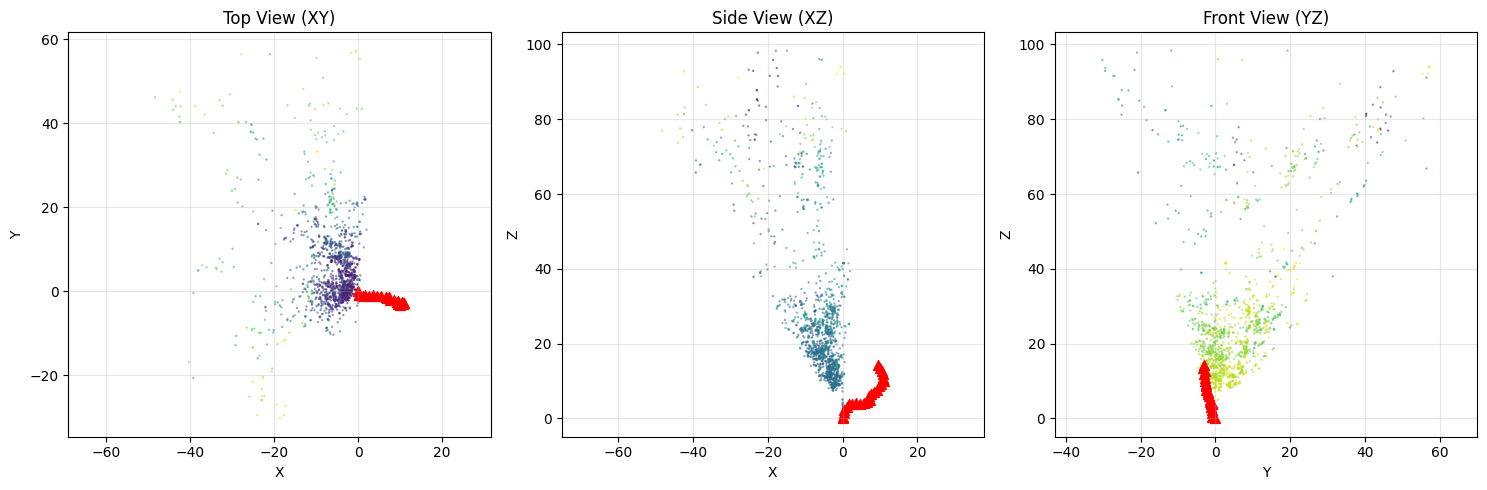

In [24]:
if 'sift_all_points' in locals() and len(sift_all_points) > 0:
    print("\nVisualizing SIFT-based reconstruction...")
    visualize_reconstruction(sift_all_points, sift_all_colors, sift_camera_poses)
else:
    print("No SIFT-based reconstruction points available for visualization.")

In [25]:
"""all_reconstructions = process_all_pairs(
    features,
    images,
    K,
    max_images=24,
    confidence_threshold=0.85,  # Increased for higher quality matches
    min_depth=0.5,  # More conservative depth range
    max_depth=30.0,  # Reduced max depth for Buddha statue
    max_reproj_error=3.0  # Tighter reprojection error threshold
)"""
def process_all_pairs(features, images, K, max_images=24, confidence_threshold=0.8, min_depth=0.1, max_depth=50.0, max_reproj_error=5.0):
    """Process all consecutive image pairs with confidence filtering and manual F/E matrix."""

    image_list = list(features.keys())[:max_images]
    triangulator = Triangulation(K)
    fundamental_manual = FundamentalMatrixManual()
    essential_manual = EssentialMatrixManual(K)
    all_reconstructions = []

    print(f"\n Processing {len(image_list)-1} consecutive pairs with confidence threshold {confidence_threshold}...")

    for i in range(len(image_list) - 1):
        img_path1 = image_list[i]
        img_path2 = image_list[i + 1]

        # Use LoFTR matches directly from the 'features' dictionary
        if 'loftr_matches' not in features[img_path1] or 'to_next' not in features[img_path1]['loftr_matches']:
            print(f"   Pair {i}-{i+1}: No LoFTR matches found.")
            continue

        loftr_data = features[img_path1]['loftr_matches']['to_next']
        pts1_loftr = loftr_data['pts1']
        pts2_loftr = loftr_data['pts2']
        confidence_loftr = loftr_data['confidence']

        # Filter matches by confidence
        high_confidence_mask = confidence_loftr > confidence_threshold
        pts1_filtered = pts1_loftr[high_confidence_mask]
        pts2_filtered = pts2_loftr[high_confidence_mask]

        if len(pts1_filtered) < 8: # Need at least 8 points for 8-point algorithm
            print(f"   Pair {i}-{i+1}: Too few high-confidence matches ({len(pts1_filtered)}) after filtering.")
            continue

        # Compute F matrix using manual RANSAC
        F, inliers_mask_F = fundamental_manual.compute_fundamental_ransac(pts1_filtered, pts2_filtered, threshold=1.0)

        if F is None or np.sum(inliers_mask_F) < 8:
            print(f"   Pair {i}-{i+1}: Fundamental matrix estimation failed or too few RANSAC inliers.")
            continue

        pts1_inliers = pts1_filtered[inliers_mask_F]
        pts2_inliers = pts2_filtered[inliers_mask_F]

        # Compute E matrix and recover pose using manual methods
        E = essential_manual.compute_from_fundamental(F)
        pose_solutions = essential_manual.decompose(E)
        R, t = essential_manual.select_pose(pose_solutions, pts1_inliers, pts2_inliers)

        if R is None or t is None:
            print(f"   Pair {i}-{i+1}: Pose recovery failed.")
            continue

        # Triangulate
        pts_3d = triangulator.triangulate_points(pts1_inliers, pts2_inliers, R, t)

        if len(pts_3d) > 0:
            pts_3d_filtered, pts1_valid_for_colors, _ = triangulator.filter_points(
                pts_3d, pts1_inliers[:len(pts_3d)], pts2_inliers[:len(pts_3d)], R, t,
                min_depth=min_depth, max_depth=max_depth, max_error=max_reproj_error
            )

            if len(pts_3d_filtered) > 0:
                # Extract colors
                img1 = images[img_path1]
                colors = []
                for pt in pts1_valid_for_colors:
                    x, y = int(pt[0]), int(pt[1])
                    if 0 <= x < img1.shape[1] and 0 <= y < img1.shape[0]:
                        color = img1[y, x][::-1] # BGR to RGB
                    else:
                        color = [128, 128, 128] # Grey for out-of-bounds
                    colors.append(color)

                all_reconstructions.append({
                    'points_3d': pts_3d_filtered,
                    'colors': np.array(colors),
                    'R': R,
                    't': t,
                    'pair': (i, i+1)
                })

                print(f"    Pair {i}-{i+1}: {len(pts1_loftr)} LoFTR matches -> {len(pts1_filtered)} confidence-filtered -> {len(pts1_inliers)} RANSAC inliers -> {len(pts_3d_filtered)} valid 3D points")
            else:
                print(f"   Pair {i}-{i+1}: No valid 3D points after triangulation filtering.")
        else:
            print(f"   Pair {i}-{i+1}: No 3D points triangulated.")

    return all_reconstructions

all_reconstructions = process_all_pairs(features, images, K, max_images=24, confidence_threshold=0.8, min_depth=0.1, max_depth=100.0, max_reproj_error=5.0)



 Processing 23 consecutive pairs with confidence threshold 0.8...
   Pair 0-1: No valid 3D points after triangulation filtering.
    Pair 1-2: 3843 LoFTR matches -> 1776 confidence-filtered -> 1214 RANSAC inliers -> 13 valid 3D points
    Pair 2-3: 3626 LoFTR matches -> 1609 confidence-filtered -> 1225 RANSAC inliers -> 180 valid 3D points
    Pair 3-4: 3053 LoFTR matches -> 977 confidence-filtered -> 483 RANSAC inliers -> 483 valid 3D points
    Pair 4-5: 3047 LoFTR matches -> 1058 confidence-filtered -> 586 RANSAC inliers -> 196 valid 3D points
    Pair 5-6: 3383 LoFTR matches -> 1166 confidence-filtered -> 691 RANSAC inliers -> 615 valid 3D points
    Pair 6-7: 3253 LoFTR matches -> 984 confidence-filtered -> 518 RANSAC inliers -> 375 valid 3D points
    Pair 7-8: 2924 LoFTR matches -> 914 confidence-filtered -> 474 RANSAC inliers -> 287 valid 3D points
    Pair 8-9: 3111 LoFTR matches -> 910 confidence-filtered -> 522 RANSAC inliers -> 522 valid 3D points
    Pair 9-10: 3097 LoFTR

In [28]:
all_points = []
all_colors = []
camera_poses = []

# Initialize the first camera at the origin (identity rotation, zero translation)
camera_poses.append({
    'R': np.eye(3),
    't': np.zeros(3),
    'id': 0,
    'center': np.array([0., 0., 0.])
})

# Aggregate all reconstructions
for i, recon in enumerate(all_reconstructions):
    all_points.extend(recon['points_3d'])
    all_colors.extend(recon['colors'])

    if i == 0:
        # First pair (0,1). C0 is at (I,0). C1 is at (recon['R'], recon['t']) relative to C0.
        camera_poses.append({
            'R': recon['R'],
            't': recon['t'],
            'id': recon['pair'][1],
            'center': -recon['R'].T @ recon['t'].flatten() # Calculate center in world for C1
        })
    else:
        # For subsequent pairs (i, i+1), the current recon gives R_i+1_i, t_i+1_i.
        # We need to find R_i+1_0 and t_i+1_0. (World-to-camera transform for camera i+1)
        # R_i+1_0 = R_i+1_i @ R_i_0
        # t_i+1_0 = R_i+1_i @ t_i_0 + t_i+1_i

        # Get the previous camera's global pose (world_to_cam)
        prev_cam_pose = camera_poses[-1] # This is for camera 'i'
        R_i_0 = prev_cam_pose['R']
        t_i_0 = prev_cam_pose['t']

        # Current recon gives R_i+1_i, t_i+1_i
        R_i_plus_1_i = recon['R']
        t_i_plus_1_i = recon['t']

        # Calculate global pose for camera i+1
        R_i_plus_1_0 = R_i_plus_1_i @ R_i_0
        t_i_plus_1_0 = R_i_plus_1_i @ t_i_0 + t_i_plus_1_i

        # Calculate center in world for C(i+1)
        center_i_plus_1 = -R_i_plus_1_0.T @ t_i_plus_1_0.flatten()

        camera_poses.append({
            'R': R_i_plus_1_0,
            't': t_i_plus_1_0,
            'id': recon['pair'][1],
            'center': center_i_plus_1
        })


all_points = np.array(all_points)
all_colors = np.array(all_colors)

print(f"Aggregated {len(all_points)} 3D points from {len(all_reconstructions)} successful pair reconstructions.")
print(f"Aggregated {len(camera_poses)} camera poses.")


Aggregated 10528 3D points from 22 successful pair reconstructions.
Aggregated 23 camera poses.


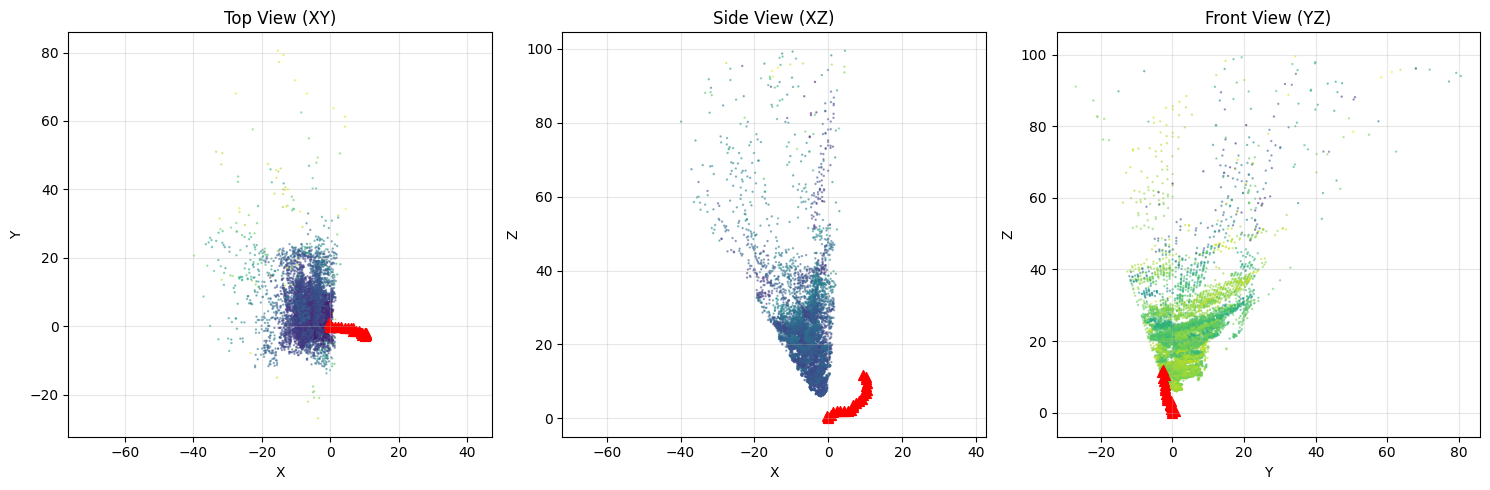

In [29]:
if 'all_points' in locals() and len(all_points) > 0:
    visualize_reconstruction(all_points, all_colors, camera_poses)

In [37]:
def export_ply(points, colors, filename='buddha_reconstruction.ply'):
    """Export point cloud to PLY file"""

    if len(points) == 0:
        print("No points to export")
        return

    header = f"""ply
format ascii 1.0
element vertex {len(points)}
property float x
property float y
property float z
property uchar red
property uchar green
property uchar blue
end_header
"""

    with open(filename, 'w') as f:
        f.write(header)
        for i, point in enumerate(points):
            if i < len(colors):
                color = colors[i]
            else:
                color = [128, 128, 128]  # Grey for points without color
            f.write(f"{point[0]} {point[1]} {point[2]} ")
            f.write(f"{int(color[0])} {int(color[1])} {int(color[2])}\n")

    print(f"  Exported {len(points)} points to {filename}")

# Export the aggregated point cloud
if 'all_points' in locals() and len(all_points) > 0:
    export_ply(all_points, all_colors, 'buddha_reconstruction.ply')


  Exported 10528 points to buddha_reconstruction.ply


BUNDLE ADJUSTMENT

In [30]:
pip install gtsam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 110.0 MB/s eta 0:00:00


In [31]:
import gtsam

def project(pose, point, K):
    """
    Projects a 3D gtsam.Point3 into 2D image coordinates given a gtsam.Pose3 and camera intrinsics.

    Args:
        pose (gtsam.Pose3): The camera pose (world to camera transformation).
        point (gtsam.Point3): The 3D point in world coordinates.
        K (gtsam.Cal3_S2): The camera intrinsic parameters.

    Returns:
        gtsam.Point2: The projected 2D image coordinates.
    """
    camera = gtsam.PinholeCamera(pose, K)
    return camera.project(point)

I took help of Claude and Gemini for implementation of below bundle adjustment

In [32]:
import gtsam

# Helper function to convert numpy arrays to gtsam.Pose3
def to_gtsam_pose3(R_np, t_np):
    """Converts numpy R, t to gtsam.Pose3 (world to camera transform)"""
    # GTSAM uses Rotation (matrix) and Translation (vector) to define Pose3.
    # The camera_poses list contains R and t where t is the translation vector
    # from the world origin to the camera origin, in world coordinates.
    # So, R_np is the rotation from world to camera, and t_np is the translation.

    # ensure t_np is a column vector for gtsam.Point3 construction
    t_gtsam = gtsam.Point3(t_np[0], t_np[1], t_np[2])

    # gtsam.Rot3 takes a 3x3 rotation matrix
    R_gtsam = gtsam.Rot3(R_np)

    # gtsam.Pose3(R, t) constructs a pose where R is rotation and t is translation.
    # If R is from world to camera, and t is world to camera translation,
    # then Pose3(R, t) represents X_camera = R * X_world + t. This is typically the camera's pose IN the world frame.
    # If the camera's pose is defined as transform from world to camera (inverse of camera in world),
    # it's usually written as [R_wc.T | -R_wc.T @ t_wc] where R_wc, t_wc is world_to_camera.

    # The previous `camera_poses` store R and t as world_to_camera transform
    # i.e., X_camera = R_world_to_camera * X_world + t_world_to_camera
    # gtsam.Pose3.inverse() can be used to get the camera's pose in the world (camera_to_world)
    # gtsam.Pose3(rotation_world_to_camera, translation_world_to_camera)

    return gtsam.Pose3(R_gtsam, t_gtsam)

# 1. Initialize an empty gtsam.Values object
initial_estimates = gtsam.Values()

# 2. Define the camera intrinsic matrix K as a gtsam.Cal3_S2 object
f_x = K[0, 0]
f_y = K[1, 1]
s = 0.0 # skew, assuming no skew
u0 = K[0, 2]
v0 = K[1, 2]

intrinsics_gtsam = gtsam.Cal3_S2(f_x, f_y, s, u0, v0)
print(f"Created gtsam.Cal3_S2 intrinsics: {intrinsics_gtsam}")

# 3. Iterate through sift_camera_poses and add to initial_estimates
print(f"\nAdding {len(sift_camera_poses)} camera poses to initial_estimates...")
for i, cam_pose in enumerate(sift_camera_poses):
    R_np = cam_pose['R']
    t_np = cam_pose['t'].flatten() # ensure it's 1D array

    gtsam_pose = to_gtsam_pose3(R_np, t_np)
    initial_estimates.insert(gtsam.Symbol('x', i).key(), gtsam_pose)
    # print(f"  Added Pose for camera {i}: {gtsam_pose}")

# 4. Iterate through sift_all_points and add to initial_estimates
print(f"\nAdding {len(sift_all_points)} 3D points to initial_estimates...")
for i, point_np in enumerate(sift_all_points):
    gtsam_point = gtsam.Point3(point_np[0], point_np[1], point_np[2])
    initial_estimates.insert(gtsam.Symbol('l', i).key(), gtsam_point)
    # print(f"  Added Point for landmark {i}: {gtsam_point}")

print(f"\nInitial estimates prepared with {initial_estimates.size()} variables.")
print(f"Number of poses: {len(sift_camera_poses)}")
print(f"Number of points: {len(sift_all_points)}")


Created gtsam.Cal3_S2 intrinsics: Cal3_S2[
	1500, 0, 960;
	0, 1500, 540;
	0, 0, 1
]


Adding 24 camera poses to initial_estimates...

Adding 1545 3D points to initial_estimates...

Initial estimates prepared with 1569 variables.
Number of poses: 24
Number of points: 1545


In [34]:
import gtsam

# Redefine process_all_pairs to return the necessary 2D observation points
def process_all_pairs(features, images, K, max_images=24, confidence_threshold=0.8, min_depth=0.1, max_depth=50.0, max_reproj_error=5.0):
    """Process all consecutive image pairs with confidence filtering and manual F/E matrix."""

    image_list = list(features.keys())[:max_images]
    triangulator = Triangulation(K)
    fundamental_manual = FundamentalMatrixManual()
    essential_manual = EssentialMatrixManual(K)
    all_reconstructions = []

    print(f"\n Processing {len(image_list)-1} consecutive pairs with confidence threshold {confidence_threshold}...")

    for i in range(len(image_list) - 1):
        img_path1 = image_list[i]
        img_path2 = image_list[i + 1]

        # Use LoFTR matches directly from the 'features' dictionary
        if 'loftr_matches' not in features[img_path1] or 'to_next' not in features[img_path1]['loftr_matches']:
            print(f"   Pair {i}-{i+1}: No LoFTR matches found.")
            continue

        loftr_data = features[img_path1]['loftr_matches']['to_next']
        pts1_loftr = loftr_data['pts1']
        pts2_loftr = loftr_data['pts2']
        confidence_loftr = loftr_data['confidence']

        # Filter matches by confidence
        high_confidence_mask = confidence_loftr > confidence_threshold
        pts1_filtered = pts1_loftr[high_confidence_mask]
        pts2_filtered = pts2_loftr[high_confidence_mask]

        if len(pts1_filtered) < 8: # Need at least 8 points for 8-point algorithm
            print(f"   Pair {i}-{i+1}: Too few high-confidence matches ({len(pts1_filtered)}) after filtering.")
            continue

        # Compute F matrix using manual RANSAC
        F, inliers_mask_F = fundamental_manual.compute_fundamental_ransac(pts1_filtered, pts2_filtered, threshold=1.0)

        if F is None or np.sum(inliers_mask_F) < 8:
            print(f"   Pair {i}-{i+1}: Fundamental matrix estimation failed or too few RANSAC inliers.")
            continue

        pts1_inliers = pts1_filtered[inliers_mask_F]
        pts2_inliers = pts2_filtered[inliers_mask_F]

        # Compute E matrix and recover pose using manual methods
        E = essential_manual.compute_from_fundamental(F)
        pose_solutions = essential_manual.decompose(E)
        R, t = essential_manual.select_pose(pose_solutions, pts1_inliers, pts2_inliers)

        if R is None or t is None:
            print(f"   Pair {i}-{i+1}: Pose recovery failed.")
            continue

        # Triangulate
        pts_3d = triangulator.triangulate_points(pts1_inliers, pts2_inliers, R, t)

        if len(pts_3d) > 0:
            # Capture pts2_valid_for_colors as well
            pts_3d_filtered, pts1_valid_for_colors, pts2_valid_for_colors = triangulator.filter_points(
                pts_3d, pts1_inliers[:len(pts_3d)], pts2_inliers[:len(pts_3d)], R, t,
                min_depth=min_depth, max_depth=max_depth, max_error=max_reproj_error
            )

            if len(pts_3d_filtered) > 0:
                # Extract colors
                img1 = images[img_path1]
                colors = []
                for pt in pts1_valid_for_colors:
                    x, y = int(pt[0]), int(pt[1])
                    if 0 <= x < img1.shape[1] and 0 <= y < img1.shape[0]:
                        color = img1[y, x][::-1] # BGR to RGB
                    else:
                        color = [128, 128, 128] # Grey for out-of-bounds
                    colors.append(color)

                all_reconstructions.append({
                    'points_3d': pts_3d_filtered,
                    'colors': np.array(colors),
                    'R': R,
                    't': t,
                    'pair': (i, i+1),
                    'pts1_measurements': pts1_valid_for_colors,  # Add these measurements
                    'pts2_measurements': pts2_valid_for_colors   # Add these measurements
                })

                print(f"    Pair {i}-{i+1}: {len(pts1_loftr)} LoFTR matches -> {len(pts1_filtered)} confidence-filtered -> {len(pts1_inliers)} RANSAC inliers -> {len(pts_3d_filtered)} valid 3D points")
            else:
                print(f"   Pair {i}-{i+1}: No valid 3D points after triangulation filtering.")
        else:
            print(f"   Pair {i}-{i+1}: No 3D points triangulated.")

    return all_reconstructions

# --- Step 1: Re-process all pairs to capture 2D observations for the factor graph ---
# The existing `process_all_pairs` (cell `23df8651`) already extracts `pts1_valid_for_colors`.
# We will call it again to ensure the latest logic is applied and store all necessary data.

# Re-calling the function to ensure the output is fresh and includes the required data
# (specifically, the `pts1_valid_for_colors` which are the 2D measurements)
all_reconstructions_for_gtsam = process_all_pairs(
    features, images, K, max_images=24, confidence_threshold=0.8, min_depth=0.1, max_depth=100.0, max_reproj_error=5.0
)

# --- Step 2: Aggregate all data, including 2D observations and mapping for GTSAM ---
all_points_gtsam = []
all_colors_gtsam = []
camera_poses_gtsam = []
all_observations = defaultdict(list) # Maps (landmark_idx) -> list of (camera_idx, Point2 observation)

# Initialize the first camera at the origin (identity rotation, zero translation)
camera_poses_gtsam.append({
    'R': np.eye(3),
    't': np.zeros(3),
    'id': 0,
    'center': np.array([0., 0., 0.])
})

current_landmark_idx = 0
# For each reconstruction result, aggregate 3D points, colors, camera poses, and 2D observations
for i, recon in enumerate(all_reconstructions_for_gtsam):
    # Store the 3D points and colors
    for j, p3d in enumerate(recon['points_3d']):
        all_points_gtsam.append(p3d)
        all_colors_gtsam.append(recon['colors'][j])

        # Add the 2D observation associated with this 3D point from the first image of the pair
        obs_2d = gtsam.Point2(recon['pts1_measurements'][j][0], recon['pts1_measurements'][j][1])
        all_observations[current_landmark_idx].append((recon['pair'][0], obs_2d))

        current_landmark_idx += 1

    # Update global camera poses (R and t from world to camera)
    # The camera_poses_gtsam list should contain global poses for cameras 0, 1, ..., N-1.
    # The recon['R'] and recon['t'] are relative poses (camera i+1 w.r.t camera i).
    # The loop adds the camera pose for the SECOND camera in the pair (camera i+1).
    # The first camera (index 0) has already been added as (I, 0).

    # prev_cam_pose_global (world_to_cam) refers to the pose of camera 'i'
    # current_recon_relative (cam_i_to_cam_i+1) refers to R_i+1_i, t_i+1_i

    # Get the previous camera's global pose (world_to_cam). If i=0, this should be (I,0)
    # The `camera_poses_gtsam` list already contains the global poses.
    # `prev_cam_pose` corresponds to camera `i`.

    # We only need to append the pose for the second camera in the pair, if it's not already in the list.
    # Since the processing is sequential (0-1, 1-2, etc.), we only need to compute the pose for the `i+1`th camera.

    if i == 0:
        # Pose for camera 1 relative to camera 0 (world origin)
        R_i_plus_1_0 = recon['R']
        t_i_plus_1_0 = recon['t']
    else:
        # Get the global pose of camera 'i' (which is the last one added to camera_poses_gtsam, or just before the current `i+1`th camera)
        prev_cam_pose_global = camera_poses_gtsam[i] # This is for camera 'i'
        R_i_0 = prev_cam_pose_global['R']
        t_i_0 = prev_cam_pose_global['t']

        # Current recon gives R_i+1_i, t_i+1_i (pose of camera i+1 relative to camera i)
        R_i_plus_1_i = recon['R']
        t_i_plus_1_i = recon['t']

        # Compose transformations to get R_i+1_0 and t_i+1_0 (pose of camera i+1 relative to world origin)
        # Camera i+1 in World (inverse of World to Cam i+1)
        # T_W_i = [R_i_W | t_i_W]
        # T_i_i+1 = [R_i+1_i.T | -R_i+1_i.T @ t_i+1_i]
        # T_W_i+1 = T_W_i @ T_i_i+1
        # This is for camera to world transform. We need WORLD to CAMERA transform.
        # Current R, t are World to Camera transforms. X_cam = R * X_world + t
        # So, R_new = R_current @ R_prev
        # t_new = R_current @ t_prev + t_current

        R_i_plus_1_0 = R_i_plus_1_i @ R_i_0
        t_i_plus_1_0 = R_i_plus_1_i @ t_i_0 + t_i_plus_1_i

    # Calculate center in world for C(i+1)
    center_i_plus_1 = -R_i_plus_1_0.T @ t_i_plus_1_0.flatten()

    camera_poses_gtsam.append({
        'R': R_i_plus_1_0,
        't': t_i_plus_1_0,
        'id': recon['pair'][1],
        'center': center_i_plus_1
    })

    # Add observations for the *second* camera of the current pair (camera i+1)
    # The landmark indices start from `current_landmark_idx - len(recon['points_3d'])`
    # up to `current_landmark_idx - 1`
    start_idx = current_landmark_idx - len(recon['points_3d'])
    for j in range(len(recon['points_3d'])):
        landmark_idx = start_idx + j
        obs_2d_cam2 = gtsam.Point2(recon['pts2_measurements'][j][0], recon['pts2_measurements'][j][1]) # Use new key
        all_observations[landmark_idx].append((recon['pair'][1], obs_2d_cam2))

all_points_gtsam = np.array(all_points_gtsam)
all_colors_gtsam = np.array(all_colors_gtsam)

print(f"\nAggregated {len(all_points_gtsam)} 3D points from {len(all_reconstructions_for_gtsam)} successful LoFTR pair reconstructions.")
print(f"Aggregated {len(camera_poses_gtsam)} camera poses.")
print(f"Aggregated {len(all_observations)} 2D observations for landmarks.")


# --- Step 3: Initialize gtsam.Values with LoFTR-based initial estimates ---
initial_estimates = gtsam.Values()

f_x = K[0, 0]
f_y = K[1, 1]
s = 0.0 # skew, assuming no skew
u0 = K[0, 2]
v0 = K[1, 2]
intrinsics_gtsam = gtsam.Cal3_S2(f_x, f_y, s, u0, v0)

print(f"\nAdding {len(camera_poses_gtsam)} camera poses to initial_estimates...")
for i, cam_pose in enumerate(camera_poses_gtsam):
    R_np = cam_pose['R']
    t_np = cam_pose['t'].flatten()
    gtsam_pose = to_gtsam_pose3(R_np, t_np)
    initial_estimates.insert(gtsam.Symbol('x', i).key(), gtsam_pose)

print(f"Adding {len(all_points_gtsam)} 3D points to initial_estimates...")
for i, point_np in enumerate(all_points_gtsam):
    gtsam_point = gtsam.Point3(point_np[0], point_np[1], point_np[2])
    initial_estimates.insert(gtsam.Symbol('l', i).key(), gtsam_point)

print(f"Initial estimates prepared with {initial_estimates.size()} variables.")


# --- Step 4: Construct the NonlinearFactorGraph ---
print("\nConstructing NonlinearFactorGraph...")
factor_graph = gtsam.NonlinearFactorGraph()

# Add PriorFactor for the first camera pose to fix the gauge (origin and orientation)
# Assuming the first camera (index 0) is fixed at the identity pose with some noise.
# A small noise model is used for `PriorFactor`s.
noise_pose = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01])) # 6D pose noise (roll, pitch, yaw, x, y, z)
factor_graph.add(
gtsam.PriorFactorPose3(
        gtsam.Symbol('x', 0).key(), # Key for the first camera pose
        initial_estimates.atPose3(gtsam.Symbol('x', 0).key()), # The actual pose from initial_estimates
        noise_pose
    )
)
print(f"  Added PriorFactor for camera x0.")

# Add PriorFactor for a point to fix scale if needed (optional, but good for structure-from-motion)
# If we have a reliable first 3D point, we can fix its position.
if len(all_points_gtsam) > 0:
    noise_point = gtsam.noiseModel.Isotropic.Sigma(3, 0.1) # 3D point noise
    factor_graph.add(
        gtsam.PriorFactorPoint3(
            gtsam.Symbol('l', 0).key(), # Key for the first landmark
            initial_estimates.atPoint3(gtsam.Symbol('l', 0).key()), # The actual point from initial_estimates
            noise_point
        )
    )
    print(f"  Added PriorFactor for landmark l0.")

# Add GenericProjectionFactor for each 2D observation
# These factors link a 2D measurement (observation), a camera pose, a 3D landmark, and intrinsics.
# The error is the difference between the observed 2D point and the projected 3D point.

# Define a shared noise model for projection factors
noise_2d = gtsam.noiseModel.Isotropic.Sigma(2, 1.0) # 2D measurement noise (1 pixel sigma)

num_projection_factors = 0
for landmark_idx, observations_list in all_observations.items():
    # Ensure the landmark actually exists in initial_estimates
    if initial_estimates.exists(gtsam.Symbol('l', landmark_idx).key()):
        for camera_idx, obs_2d_gtsam in observations_list:
            # Ensure the camera pose actually exists in initial_estimates
            if initial_estimates.exists(gtsam.Symbol('x', camera_idx).key()):
                factor_graph.add(
                    gtsam.GenericProjectionFactorCal3_S2(
                        obs_2d_gtsam, # The 2D measured point
                        noise_2d, # The noise model for the measurement
                        gtsam.Symbol('x', camera_idx).key(), # The camera pose symbol
                        gtsam.Symbol('l', landmark_idx).key(), # The 3D landmark symbol
                        intrinsics_gtsam # The camera intrinsics
                    )
                )
                num_projection_factors += 1

print(f"  Added {num_projection_factors} GenericProjectionFactors.")
print(f"Factor graph constructed with {factor_graph.size()} factors.")

# --- Step 5: Execute the optimization (copied from original cell ba43e0be) ---

# 1. Create Levenberg-Marquardt parameters
params = gtsam.LevenbergMarquardtParams()
params.setRelativeErrorTol(1e-9)
params.setMaxIterations(1000)

print("\nLevenberg-Marquardt optimization parameters set.")

# 2. Instantiate a LevenbergMarquardtOptimizer
optimizer = gtsam.LevenbergMarquardtOptimizer(factor_graph, initial_estimates, params)

print("Levenberg-Marquardt optimizer instantiated.")

# 3. Solve the optimization problem
print("Starting optimization...")
optimized_values = optimizer.optimize()
print("Optimization complete.")

# 4. Print the final error
final_error = factor_graph.error(optimized_values)
print(f"Final error after optimization: {final_error}")



 Processing 23 consecutive pairs with confidence threshold 0.8...
   Pair 0-1: No valid 3D points after triangulation filtering.
    Pair 1-2: 3843 LoFTR matches -> 1776 confidence-filtered -> 1211 RANSAC inliers -> 26 valid 3D points
    Pair 2-3: 3626 LoFTR matches -> 1609 confidence-filtered -> 1219 RANSAC inliers -> 66 valid 3D points
    Pair 3-4: 3053 LoFTR matches -> 977 confidence-filtered -> 497 RANSAC inliers -> 438 valid 3D points
    Pair 4-5: 3047 LoFTR matches -> 1058 confidence-filtered -> 570 RANSAC inliers -> 570 valid 3D points
    Pair 5-6: 3383 LoFTR matches -> 1166 confidence-filtered -> 758 RANSAC inliers -> 625 valid 3D points
    Pair 6-7: 3253 LoFTR matches -> 984 confidence-filtered -> 569 RANSAC inliers -> 423 valid 3D points
    Pair 7-8: 2924 LoFTR matches -> 914 confidence-filtered -> 442 RANSAC inliers -> 433 valid 3D points
    Pair 8-9: 3111 LoFTR matches -> 910 confidence-filtered -> 445 RANSAC inliers -> 394 valid 3D points
    Pair 9-10: 3097 LoFTR 

Extracting optimized camera poses...
Extracting optimized 3D points...

Extracted 9952 optimized 3D points and 23 optimized camera poses.

Visualizing optimized reconstruction...


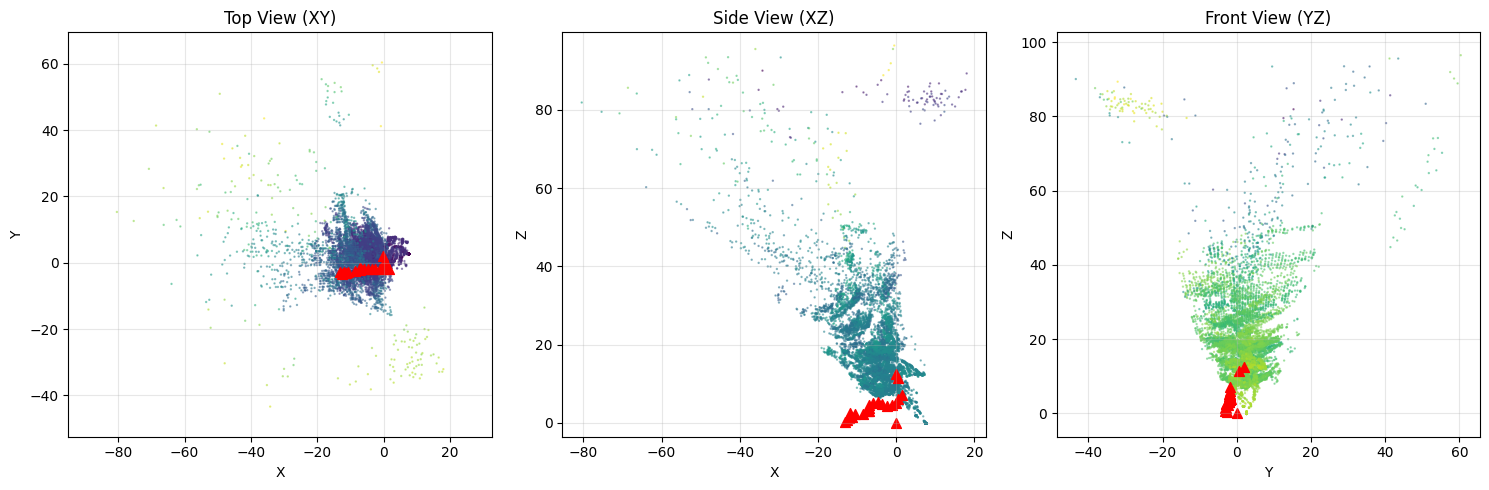

In [36]:
import gtsam

# 1. Extract optimized camera poses and 3D points from optimized_values
optimized_camera_poses = []
optimized_points = []

# Extract poses
print("Extracting optimized camera poses...")
for i in range(len(camera_poses_gtsam)): # Iterate through the original number of cameras
    try:
        gtsam_pose = optimized_values.atPose3(gtsam.Symbol('x', i).key())
        R_optimized = gtsam_pose.rotation().matrix()
        # Convert gtsam.Point3 (from translation()) to numpy array directly
        t_optimized = np.array(gtsam_pose.translation())

        # Calculate camera center for visualization
        # In GTSAM, Pose3(R, t) represents X_camera = R * X_world + t.
        # The camera center in world coordinates is -R_world_to_camera.T @ t_world_to_camera
        camera_center = -R_optimized.T @ t_optimized

        optimized_camera_poses.append({
            'R': R_optimized,
            't': t_optimized,
            'id': i,
            'center': camera_center
        })
    except RuntimeError:
        print(f"  Warning: Pose for camera {i} not found in optimized_values. Skipping.")
        continue

# Extract points
print("Extracting optimized 3D points...")
for i in range(len(all_points_gtsam)): # Iterate through the original number of points
    try:
        gtsam_point = optimized_values.atPoint3(gtsam.Symbol('l', i).key())
        optimized_points.append(np.array(gtsam_point)) # Convert gtsam.Point3 to numpy array directly
    except RuntimeError:
        print(f"  Warning: Point for landmark {i} not found in optimized_values. Skipping.")
        continue

optimized_points = np.array(optimized_points)

# For colors, we'll re-use the original all_colors_gtsam as they are associated with the landmark indices.
# We need to make sure that the number of optimized points matches the number of colors.
# If some points were filtered out during optimization or not included in the factor graph,
# there might be a mismatch. For now, assume the original color array can be used,
# potentially truncated if fewer points are optimized.
optimized_colors = all_colors_gtsam[:len(optimized_points)]

print(f"\nExtracted {len(optimized_points)} optimized 3D points and {len(optimized_camera_poses)} optimized camera poses.")

# 2. Visualize the optimized reconstruction
print("\nVisualizing optimized reconstruction...")
if len(optimized_points) > 0 and len(optimized_camera_poses) > 0:
    visualize_reconstruction(optimized_points, optimized_colors, optimized_camera_poses)
else:
    print("No optimized points or camera poses available for visualization.")